In [5]:
print('Hello world!!!')

Hello world!!!


In [4]:
# Install dependencies (if needed)
!pip install pandas matplotlib seaborn

In [6]:
import pandas as pd

# Direct CSV (World Bank-style dataset hosted online)
url = "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"

df = pd.read_csv(url)

df.head()

,Country Name,Country Code,Year,Value
0,Afghanistan,AFG,2000,3.521418e+09
1,Afghanistan,AFG,2001,2.813572e+09
2,Afghanistan,AFG,2002,3.825701e+09
3,Afghanistan,AFG,2003,4.520947e+09
4,Afghanistan,AFG,2004,5.224897e+09


In [8]:
df.shape

(13979, 4)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979 entries, 0 to 13978
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  13979 non-null  object 
 1   Country Code  13979 non-null  object 
 2   Year          13979 non-null  int64  
 3   Value         13979 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 437.0+ KB


In [12]:
df.describe()

,Year,Value
count,13979.000000,1.397900e+04
mean,1994.672866,1.207380e+12
std,17.731413,5.537517e+12
min,1960.000000,1.150263e+04
25%,1980.000000,2.233880e+09
50%,1996.000000,1.672591e+10
75%,2010.000000,2.058542e+11
max,2023.000000,1.054350e+14


In [13]:
df.isnull().sum()

,0
Country Name,0
Country Code,0
Year,0
Value,0


In [14]:
# Drop rows with missing values
df = df.dropna()

In [15]:
df.dtypes

# Make GDP numeric
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

In [ ]:
#Drop duplicates
df.duplicated().sum()

df = df.drop_duplicates()

In [16]:
african_countries = [
    "Nigeria", "Ghana", "Kenya", "South Africa", "Egypt", "Ethiopia",
    "Morocco", "Algeria", "Uganda", "Tanzania"
]

df_africa = df[df['Country Name'].isin(african_countries)]
df_africa.head()

,Country Name,Country Code,Year,Value
191,Algeria,DZA,1960,2.723615e+09
192,Algeria,DZA,1961,2.434747e+09
193,Algeria,DZA,1962,2.001445e+09
194,Algeria,DZA,1963,2.702982e+09
195,Algeria,DZA,1964,2.909316e+09


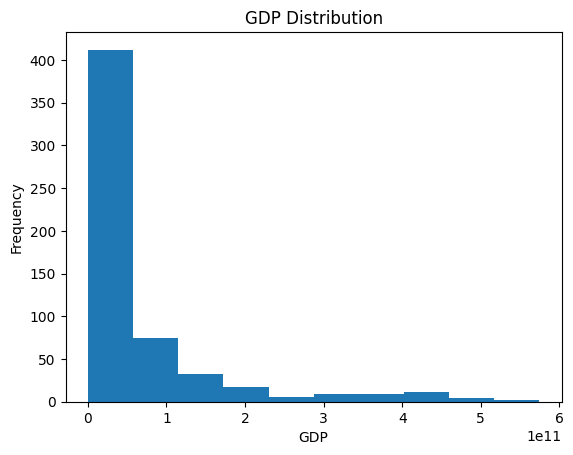

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.hist(df_africa['Value'])
plt.title("GDP Distribution")
plt.xlabel("GDP")
plt.ylabel("Frequency")
plt.show()

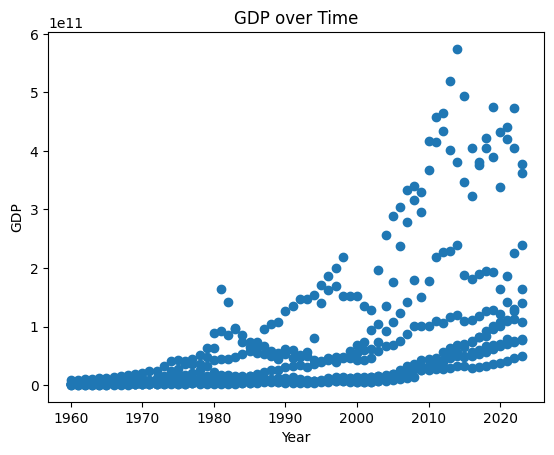

In [18]:
plt.figure()
plt.scatter(df_africa['Year'], df_africa['Value'])
plt.title("GDP over Time")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.show()

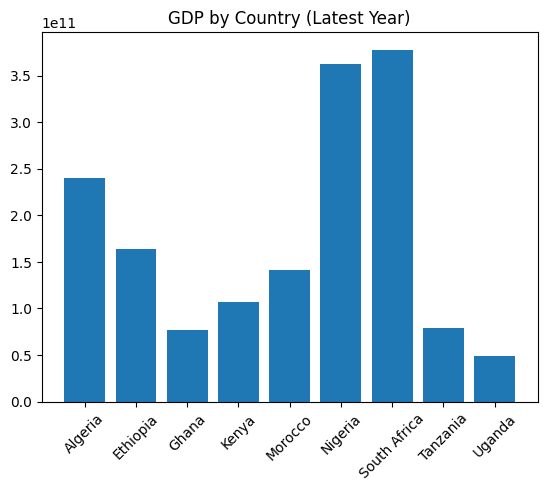

In [19]:
latest_year = df_africa[df_africa['Year'] == df_africa['Year'].max()]

plt.figure()
plt.bar(latest_year['Country Name'], latest_year['Value'])
plt.xticks(rotation=45)
plt.title("GDP by Country (Latest Year)")
plt.show()

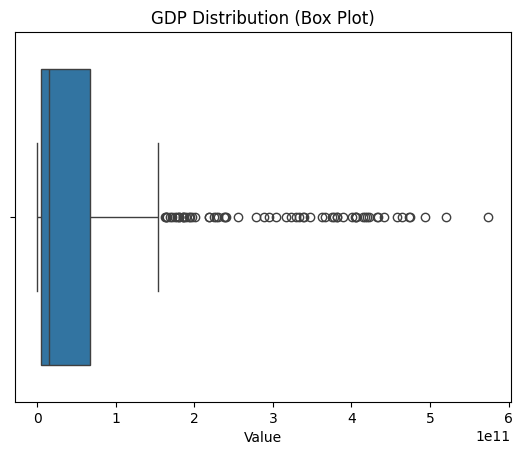

In [20]:
plt.figure()
sns.boxplot(x=df_africa['Value'])
plt.title("GDP Distribution (Box Plot)")
plt.show()


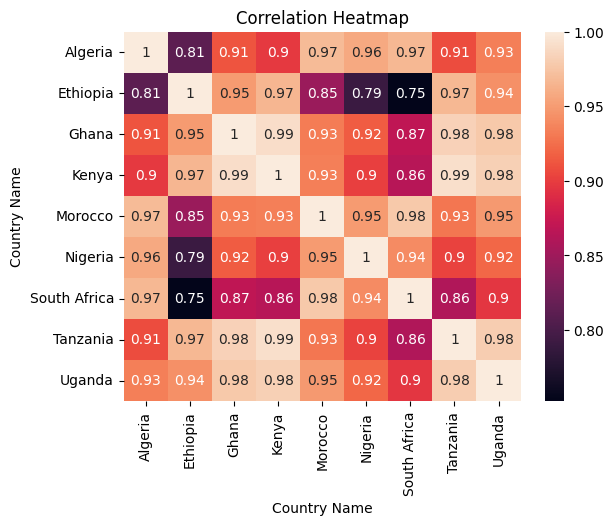

In [21]:
# Pivot data
pivot_df = df_africa.pivot_table(
    values='Value',
    index='Year',
    columns='Country Name'
)
plt.figure()
sns.heatmap(pivot_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()